In [7]:
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

In [5]:
# Set cost sensitivities
BETAS = {
    'tt': 10/3600,
    'rel': 10/3600,
    'x': 1,
    'risk': 20,
    'disc': 0
        }

# Estimate the negative exponential impedance function: impedance = exp(-beta*gtc)
max_price = 15 # per hour
max_tt_seconds = 90 * 60 # minutes
max_rel_seconds = 120 * 60 # minutes
max_risk = 0.5 # daily crashes

max_gtc = BETAS['x'] * max_price + BETAS['tt'] * max_tt_seconds + BETAS['rel'] * max_rel_seconds + BETAS['risk'] * max_risk

mid_price = 10 # per hour
mid_tt_seconds = 45 * 60 # minutes
mid_rel_seconds = 75 * 60 # minutes
mid_risk = 0.25 # daily crashes

mid_gtc = BETAS['x'] * mid_price + BETAS['tt'] * mid_tt_seconds + BETAS['rel'] * mid_rel_seconds + BETAS['risk'] * mid_risk

# Data: three gtc-impedance pairs
x = np.array([0, mid_gtc, max_gtc])  
y = np.array([1, 0.5, 0.1])  

# Transform y to ln(y)
ln_y = np.log(y)

# Add a constant for the intercept term (optional)
x_with_constant = sm.add_constant(x)  # Adds a column of ones for the intercept

# Fit the linear regression model
model = sm.OLS(ln_y, x_with_constant).fit()

# Display the summary of the model
print(model.summary())

# Extract the estimated beta
beta = model.params[1]  # The coefficient for x
print(f"Estimated beta: {beta}")

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.900
Model:                            OLS   Adj. R-squared:                  0.800
Method:                 Least Squares   F-statistic:                     8.999
Date:                Mon, 13 Jan 2025   Prob (F-statistic):              0.205
Time:                        13:03:42   Log-Likelihood:               -0.69465
No. Observations:                   3   AIC:                             5.389
Df Residuals:                       1   BIC:                             3.587
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1789      0.497      0.360      0.7

/home/lgraff/ENTER/envs/py39/lib/python3.9/site-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 3 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


Text(0, 0.5, 'Impedance Function $\\it{g(c)}$')

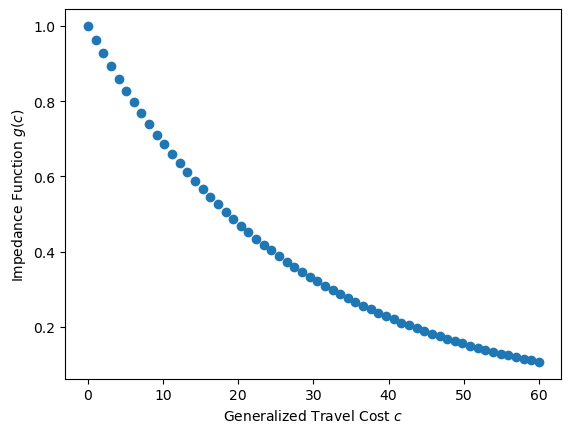

In [8]:
x = np.linspace(0,60,60)
y = np.exp(-0.0372 * x)
plt.scatter(x,y)
plt.xlabel('Generalized Travel Cost $\it{c}$')
plt.ylabel('Impedance Function $\it{g(c)}$')